# Deep Learning Pipeline

The offline preprocessing phase has been completed successfully. The dataset has been cleaned, resized, labeled, and split into training, validation, and test sets.

The following stages will be performed in a Google Colab notebook using GPU acceleration. Unlike the previous steps, preprocessing operations such as normalization and data augmentation will be applied dynamically during training without modifying the original images.

The next objective is to build the PyTorch data pipeline before developing and training the deep learning models.

## Colab Setup

Run this cell first in Google Colab. It mounts Google Drive, installs the extraction tool, and extracts `Data.rar` from your Drive into `/content/skin-disease-dataset`.

In [1]:
# =========================================================
# Google Colab setup: Drive + Data.rar extraction
# Works with either Data/images or Data/resized_images
# =========================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import subprocess
from pathlib import Path

# Change only this path if your archive has another name or location in Google Drive.
ARCHIVE_PATH = Path("/content/drive/MyDrive/Data.rar")
EXTRACT_PATH = Path("/content/skin-disease-dataset")

if not ARCHIVE_PATH.exists():
    raise FileNotFoundError(
        f"Data archive not found: {ARCHIVE_PATH}\n"
        "Please upload Data.rar to your Google Drive MyDrive, or change ARCHIVE_PATH."
    )

# Install unrar if needed
subprocess.run(["apt-get", "update", "-qq"], check=False)
subprocess.run(["apt-get", "install", "-y", "-qq", "unrar"], check=False)

# Extract only if the dataset is not already extracted
expected_data_dir = EXTRACT_PATH / "Data"
if not expected_data_dir.exists():
    EXTRACT_PATH.mkdir(parents=True, exist_ok=True)
    subprocess.run(["unrar", "x", "-y", str(ARCHIVE_PATH), str(EXTRACT_PATH) + "/"], check=True)
else:
    print("Dataset already extracted. Skipping extraction.")

# Quick verification
possible_data_dirs = [expected_data_dir] + [p for p in EXTRACT_PATH.rglob("Data") if p.is_dir()]

valid_pairs = []
for data_dir in possible_data_dirs:
    train_ok = (data_dir / "train.csv").exists()
    val_ok = (data_dir / "val.csv").exists()
    test_ok = (data_dir / "test.csv").exists()

    for image_dir_name in ["resized_images", "images"]:
        image_dir = data_dir / image_dir_name
        if train_ok and val_ok and test_ok and image_dir.exists():
            valid_pairs.append((data_dir, image_dir))

if not valid_pairs:
    print("Extracted folders:")
    for p in EXTRACT_PATH.rglob("*"):
        if p.is_dir():
            print(p)
    raise FileNotFoundError(
        "Could not find a valid Data folder containing train.csv, val.csv, test.csv, "
        "and either images/ or resized_images/."
    )

print("Valid dataset folder found:", valid_pairs[0][0])
print("Images folder:", valid_pairs[0][1])

Mounted at /content/drive
Valid dataset folder found: /content/skin-disease-dataset/Data
Images folder: /content/skin-disease-dataset/Data/images


## Dataset Loading

**Objective:** Load the training, validation, and test datasets, and define the paths to the resized images.

This step prepares the dataset for the subsequent preprocessing and model training stages.

In [2]:
# Import required libraries

import pandas as pd
from pathlib import Path

In [3]:
# Define dataset paths for Google Colab
# Works with either Data/images or Data/resized_images

from pathlib import Path

DATASET_ROOT = Path("/content/skin-disease-dataset")

# Find the correct Data folder after extraction
candidate_dirs = [DATASET_ROOT / "Data"] + [p for p in DATASET_ROOT.rglob("Data") if p.is_dir()]

DATASET_PATH = None
IMAGES_PATH = None

for p in candidate_dirs:
    train_csv = p / "train.csv"
    val_csv = p / "val.csv"
    test_csv = p / "test.csv"

    for image_dir_name in ["resized_images", "images"]:
        img_dir = p / image_dir_name

        if train_csv.exists() and val_csv.exists() and test_csv.exists() and img_dir.exists():
            DATASET_PATH = p
            IMAGES_PATH = img_dir
            break

    if DATASET_PATH is not None:
        break

if DATASET_PATH is None:
    print("Available folders:")
    for folder in DATASET_ROOT.rglob("*"):
        if folder.is_dir():
            print(folder)

    raise FileNotFoundError(
        "Could not find Data folder with train.csv, val.csv, test.csv and "
        "either images/ or resized_images/. Run the Colab setup cell first and check Data.rar."
    )

TRAIN_CSV = DATASET_PATH / "train.csv"
VAL_CSV = DATASET_PATH / "val.csv"
TEST_CSV = DATASET_PATH / "test.csv"

print("DATASET_PATH:", DATASET_PATH)
print("IMAGES_PATH:", IMAGES_PATH)
print("TRAIN_CSV exists:", TRAIN_CSV.exists())
print("VAL_CSV exists:", VAL_CSV.exists())
print("TEST_CSV exists:", TEST_CSV.exists())
print("IMAGES_PATH exists:", IMAGES_PATH.exists())

DATASET_PATH: /content/skin-disease-dataset/Data
IMAGES_PATH: /content/skin-disease-dataset/Data/images
TRAIN_CSV exists: True
VAL_CSV exists: True
TEST_CSV exists: True
IMAGES_PATH exists: True


In [4]:
# Load datasets

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

In [5]:
# Display dataset information

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head(1)

(2113, 3)
(264, 3)
(265, 3)


,image_id,disease,target
0,ISIC_6269166,melanoma,0


## Image Normalization & Data Augmentation
**Objective:** Define the image transformations (normalization and augmentation) that will be applied dynamically during training, without modifying the original images on disk.
This step only prepares transformation pipelines in code — they will be executed later, image by image, when the DataLoader feeds data into the model.

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Unique image size chosen for all 3 models (ResNet-50, EfficientNet-B4, ViT-B/16)
IMG_SIZE = 224

# ImageNet normalization stats (required since models are pretrained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform for TRAIN: augmentation + normalization
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),                 # safety resize
    A.HorizontalFlip(p=0.5),                      # random horizontal flip
    A.VerticalFlip(p=0.2),                        # random vertical flip
    A.RandomRotate90(p=0.3),                      # random 90° rotation
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),  # shift/zoom/rotate (new API)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),  # brightness/contrast variation
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),  # color variation
    A.GaussNoise(std_range=(0.1, 0.2), p=0.2),    # slight noise (new API)
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # normalization
    ToTensorV2(),                                  # convert to PyTorch tensor
])

# Transform for VAL/TEST: normalization only, no augmentation
val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

## Dataset Class
**Objective:** Create a PyTorch `Dataset` class that loads images from the detected image folder (`images/` or `resized_images/`) using `image_id`, applies the transforms defined in the previous step, and returns the image tensor along with its label.
This class will be used by the DataLoader to feed batches of data into the model during training and evaluation.

In [7]:
import os
import cv2
import pandas as pd
from torch.utils.data import Dataset

class SkinDiseaseDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")  # add .jpg extension

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = int(row["target"])

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [8]:
# Instantiate datasets for each split

DATA_DIR = str(DATASET_PATH)
IMG_DIR = str(IMAGES_PATH)

train_dataset = SkinDiseaseDataset(str(TRAIN_CSV), IMG_DIR, transform=train_transform)
val_dataset   = SkinDiseaseDataset(str(VAL_CSV),   IMG_DIR, transform=val_test_transform)
test_dataset  = SkinDiseaseDataset(str(TEST_CSV),  IMG_DIR, transform=val_test_transform)

print(len(train_dataset), len(val_dataset), len(test_dataset))

2113 264 265


## DataLoader
**Objective:** Wrap the train, validation, and test datasets into PyTorch `DataLoader` objects, which handle batching, shuffling, and parallel loading during training and evaluation.
This step makes the data ready to be fed directly into the models.

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,        # shuffle order each epoch (train only)
    num_workers=2,        # parallel data loading
    pin_memory=True       # speeds up transfer to GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,        # no need to shuffle for validation
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # no need to shuffle for test
    num_workers=2,
    pin_memory=True
)

In [10]:
# Quick check: load one batch and inspect shapes
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)   # ex: [32, 3, 224, 224]
print("Labels shape:", labels.shape)   # ex: [32]

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Model Development
**Objective:** Load three pretrained architectures (ResNet-50, EfficientNet-B4, ViT-B/16), replace their final classification layer to output 3 classes (melanoma, carcinoma, eczema), and define the loss function and optimizer used for training.
This step prepares the models before the actual training loop.

In [11]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
# ResNet-50
def get_resnet50():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(device)

# EfficientNet-B4
def get_efficientnet_b4():
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model.to(device)

# ViT-B/16
def get_vit_b16():
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    return model.to(device)

In [13]:
# Loss function — weighted to handle class imbalance
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_dataset.df["target"]),
    y=train_dataset.df["target"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([1.5082, 1.7137, 0.5703], device='cuda:0')


In [14]:
# Optimizer — instantiate one per model during training
def get_optimizer(model, lr=1e-4):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

## Model Training — Training Loop Function
**Objective:** Define a reusable function that trains a given model, evaluates it on the validation set after each epoch, applies early stopping, and keeps the best weights.

In [15]:
import copy
import torch

def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, num_epochs=20, patience=5):
    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        # ---- TRAIN ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        # ---- VALIDATION ----
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_loss, val_acc = val_loss_sum / val_total, val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # ---- EARLY STOPPING ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹ Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_weights)
    return model, history

## Train ResNet-50
**Objective:** Train the ResNet-50 model and save its best weights.

In [16]:
resnet_model = get_resnet50()
resnet_optimizer = get_optimizer(resnet_model)

resnet_model, resnet_history = train_model(
    resnet_model, "ResNet-50", train_loader, val_loader,
    criterion, resnet_optimizer, num_epochs=20, patience=5
)

torch.save(resnet_model.state_dict(), "resnet50_best.pth")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


[ResNet-50] Epoch 1/20 | Train Loss: 0.4787 Acc: 0.8434 | Val Loss: 0.1549 Acc: 0.9697
[ResNet-50] Epoch 2/20 | Train Loss: 0.1693 Acc: 0.9574 | Val Loss: 0.0599 Acc: 0.9924
[ResNet-50] Epoch 3/20 | Train Loss: 0.1180 Acc: 0.9664 | Val Loss: 0.0384 Acc: 0.9924
[ResNet-50] Epoch 4/20 | Train Loss: 0.1203 Acc: 0.9669 | Val Loss: 0.0401 Acc: 0.9924
[ResNet-50] Epoch 5/20 | Train Loss: 0.0811 Acc: 0.9787 | Val Loss: 0.0366 Acc: 0.9924
[ResNet-50] Epoch 6/20 | Train Loss: 0.0859 Acc: 0.9792 | Val Loss: 0.0197 Acc: 0.9962
[ResNet-50] Epoch 7/20 | Train Loss: 0.0772 Acc: 0.9796 | Val Loss: 0.0576 Acc: 0.9924
[ResNet-50] Epoch 8/20 | Train Loss: 0.0502 Acc: 0.9872 | Val Loss: 0.0239 Acc: 0.9962
[ResNet-50] Epoch 9/20 | Train Loss: 0.0519 Acc: 0.9853 | Val Loss: 0.0223 Acc: 0.9962
[ResNet-50] Epoch 10/20 | Train Loss: 0.0721 Acc: 0.9815 | Val Loss: 0.0653 Acc: 0.9848
[ResNet-50] Epoch 11/20 | Train Loss: 0.0535 Acc: 0.9839 | Val Loss: 0.0181 Acc: 0.9924
[ResNet-50] Epoch 12/20 | Train Loss: 0.0

## Train EfficientNet-B4
**Objective:** Train the EfficientNet-B4 model and save its best weights.

In [17]:
efficientnet_model = get_efficientnet_b4()
efficientnet_optimizer = get_optimizer(efficientnet_model)

efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, "EfficientNet-B4", train_loader, val_loader,
    criterion, efficientnet_optimizer, num_epochs=20, patience=5
)

torch.save(efficientnet_model.state_dict(), "efficientnet_b4_best.pth")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 168MB/s]


[EfficientNet-B4] Epoch 1/20 | Train Loss: 0.9286 Acc: 0.7496 | Val Loss: 0.6405 Acc: 0.9015
[EfficientNet-B4] Epoch 2/20 | Train Loss: 0.5645 Acc: 0.8850 | Val Loss: 0.3347 Acc: 0.9470
[EfficientNet-B4] Epoch 3/20 | Train Loss: 0.3165 Acc: 0.9300 | Val Loss: 0.1284 Acc: 0.9735
[EfficientNet-B4] Epoch 4/20 | Train Loss: 0.2027 Acc: 0.9437 | Val Loss: 0.0826 Acc: 0.9735
[EfficientNet-B4] Epoch 5/20 | Train Loss: 0.1618 Acc: 0.9498 | Val Loss: 0.0517 Acc: 0.9848
[EfficientNet-B4] Epoch 6/20 | Train Loss: 0.1267 Acc: 0.9659 | Val Loss: 0.0472 Acc: 0.9924
[EfficientNet-B4] Epoch 7/20 | Train Loss: 0.1470 Acc: 0.9546 | Val Loss: 0.0469 Acc: 0.9924
[EfficientNet-B4] Epoch 8/20 | Train Loss: 0.1015 Acc: 0.9726 | Val Loss: 0.0527 Acc: 0.9886
[EfficientNet-B4] Epoch 9/20 | Train Loss: 0.1254 Acc: 0.9598 | Val Loss: 0.0320 Acc: 0.9924
[EfficientNet-B4] Epoch 10/20 | Train Loss: 0.0990 Acc: 0.9688 | Val Loss: 0.0403 Acc: 0.9924
[EfficientNet-B4] Epoch 11/20 | Train Loss: 0.1131 Acc: 0.9626 | Val 

## Train ViT-B/16
**Objective:** Train the ViT-B/16 model and save its best weights.

In [18]:
vit_model = get_vit_b16()
vit_optimizer = get_optimizer(vit_model)

vit_model, vit_history = train_model(
    vit_model, "ViT-B/16", train_loader, val_loader,
    criterion, vit_optimizer, num_epochs=20, patience=5
)

torch.save(vit_model.state_dict(), "vit_b16_best.pth")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 61.4MB/s]


[ViT-B/16] Epoch 1/20 | Train Loss: 0.2539 Acc: 0.9271 | Val Loss: 0.0507 Acc: 0.9811
[ViT-B/16] Epoch 2/20 | Train Loss: 0.1175 Acc: 0.9697 | Val Loss: 0.0506 Acc: 0.9811
[ViT-B/16] Epoch 3/20 | Train Loss: 0.1148 Acc: 0.9711 | Val Loss: 0.0339 Acc: 0.9924
[ViT-B/16] Epoch 4/20 | Train Loss: 0.1211 Acc: 0.9726 | Val Loss: 0.1073 Acc: 0.9773
[ViT-B/16] Epoch 5/20 | Train Loss: 0.1023 Acc: 0.9735 | Val Loss: 0.0675 Acc: 0.9886
[ViT-B/16] Epoch 6/20 | Train Loss: 0.1021 Acc: 0.9721 | Val Loss: 0.0553 Acc: 0.9924
[ViT-B/16] Epoch 7/20 | Train Loss: 0.0742 Acc: 0.9787 | Val Loss: 0.0926 Acc: 0.9735
[ViT-B/16] Epoch 8/20 | Train Loss: 0.0690 Acc: 0.9820 | Val Loss: 0.1260 Acc: 0.9735
⏹ Early stopping at epoch 8


## Training Curves
**Objective:** Visualize train/validation loss and accuracy for each model to check for overfitting/underfitting.

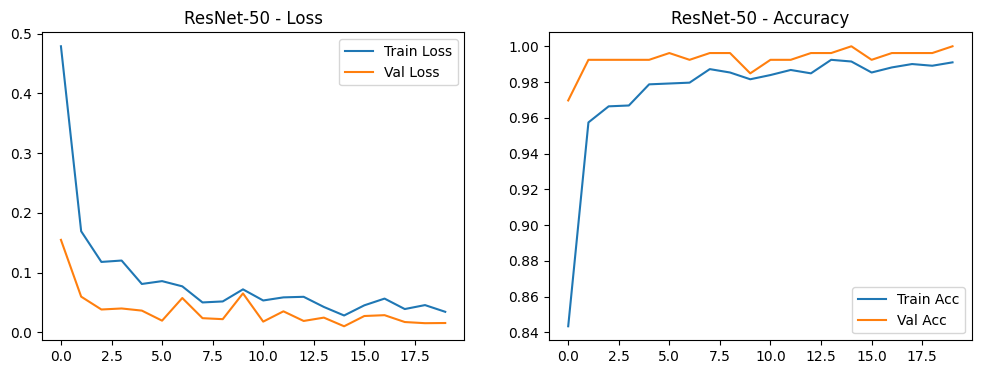

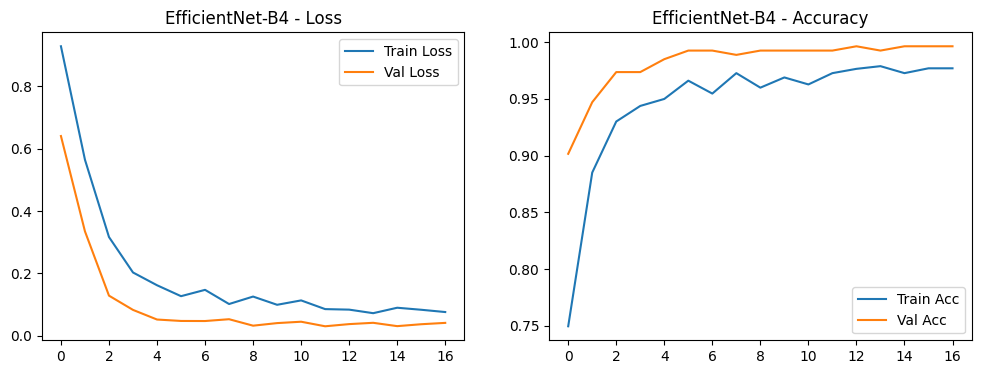

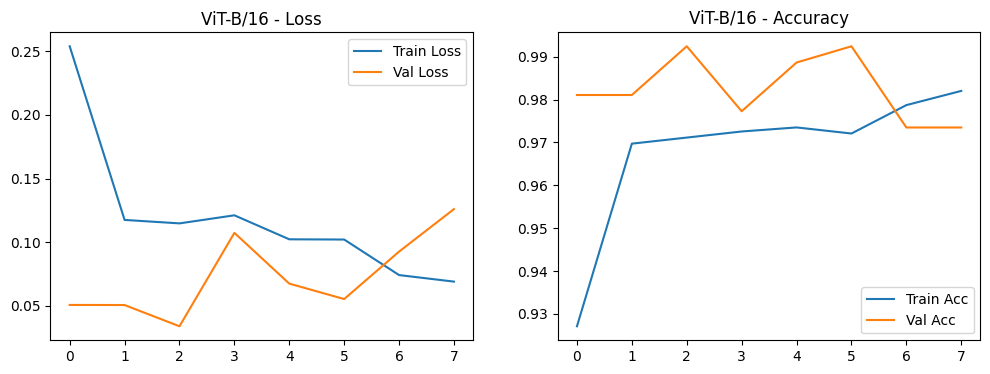

In [19]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.show()

plot_history(resnet_history, "ResNet-50")
plot_history(efficientnet_history, "EfficientNet-B4")
plot_history(vit_history, "ViT-B/16")

## Model Evaluation — Run Inference on Test Set
**Objective:** Run the 3 trained models on the test set (data never seen during training) to collect predictions, true labels, and probabilities, needed for all metrics below.

In [20]:
import torch
import numpy as np

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [21]:
resnet_labels, resnet_preds, resnet_probs = evaluate_model(resnet_model, test_loader, device)
efficientnet_labels, efficientnet_preds, efficientnet_probs = evaluate_model(efficientnet_model, test_loader, device)
vit_labels, vit_preds, vit_probs = evaluate_model(vit_model, test_loader, device)

## Classification Metrics
**Objective:** Compute Accuracy, Precision, Recall, and F1-score for each model on the test set.

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def print_metrics(labels, preds, model_name):
    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average="weighted")
    recall = recall_score(labels, preds, average="weighted")
    f1 = f1_score(labels, preds, average="weighted")

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(labels, preds, target_names=["melanoma", "carcinoma", "eczema"]))
    print()

In [23]:
print_metrics(resnet_labels, resnet_preds, "ResNet-50")
print_metrics(efficientnet_labels, efficientnet_preds, "EfficientNet-B4")
print_metrics(vit_labels, vit_preds, "ViT-B/16")

--- ResNet-50 ---
Accuracy:  0.9925
Precision: 0.9927
Recall:    0.9925
F1-score:  0.9924
              precision    recall  f1-score   support

    melanoma       0.97      1.00      0.98        59
   carcinoma       1.00      0.96      0.98        51
      eczema       1.00      1.00      1.00       155

    accuracy                           0.99       265
   macro avg       0.99      0.99      0.99       265
weighted avg       0.99      0.99      0.99       265


--- EfficientNet-B4 ---
Accuracy:  0.9849
Precision: 0.9851
Recall:    0.9849
F1-score:  0.9849
              precision    recall  f1-score   support

    melanoma       0.95      0.98      0.97        59
   carcinoma       0.98      0.94      0.96        51
      eczema       1.00      1.00      1.00       155

    accuracy                           0.98       265
   macro avg       0.98      0.97      0.98       265
weighted avg       0.99      0.98      0.98       265


--- ViT-B/16 ---
Accuracy:  0.9736
Precision: 0.97

## Confusion Matrix
**Objective:** Visualize where each model makes correct/incorrect predictions per class.

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["melanoma", "carcinoma", "eczema"],
                yticklabels=["melanoma", "carcinoma", "eczema"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

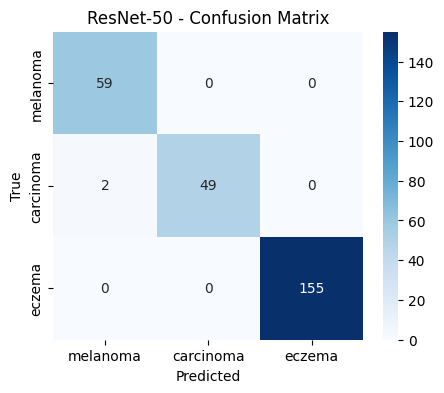

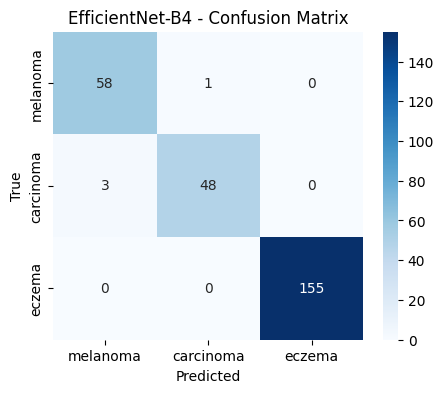

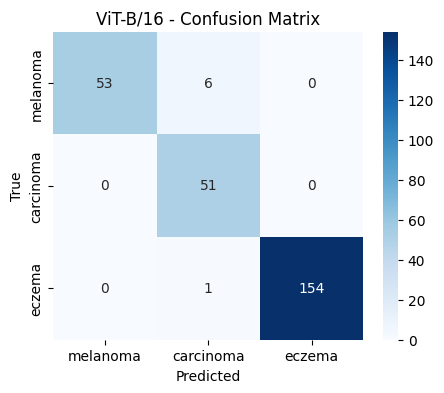

In [25]:
plot_confusion_matrix(resnet_labels, resnet_preds, "ResNet-50")
plot_confusion_matrix(efficientnet_labels, efficientnet_preds, "EfficientNet-B4")
plot_confusion_matrix(vit_labels, vit_preds, "ViT-B/16")

## ROC Curve
**Objective:** Plot ROC curve per class (one-vs-rest) for each model, and compute AUC to measure class separability.

In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(labels, probs, model_name, class_names=["melanoma", "carcinoma", "eczema"]):
    labels_bin = label_binarize(labels, classes=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

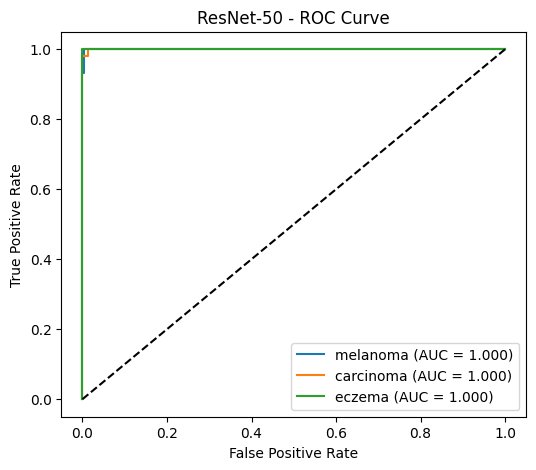

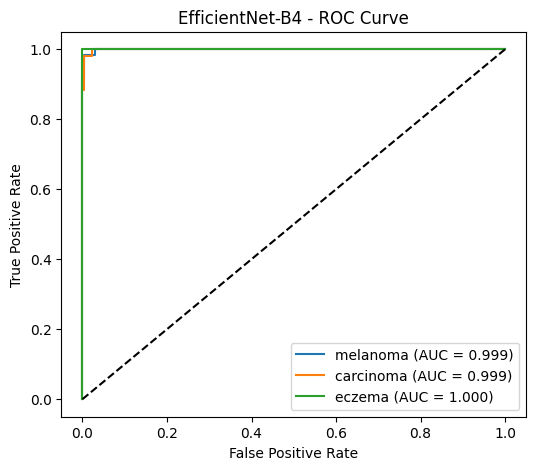

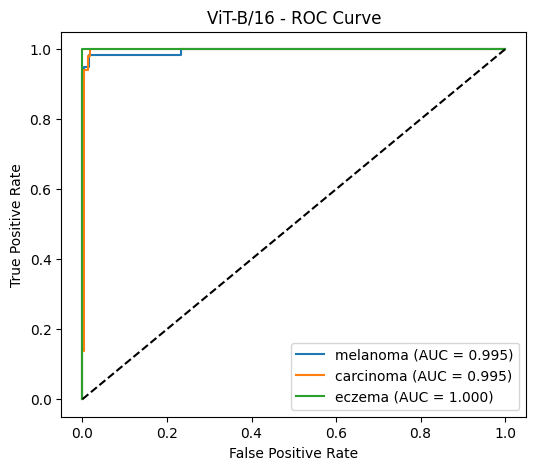

In [27]:
plot_roc_curve(resnet_labels, resnet_probs, "ResNet-50")
plot_roc_curve(efficientnet_labels, efficientnet_probs, "EfficientNet-B4")
plot_roc_curve(vit_labels, vit_probs, "ViT-B/16")

## Model Comparison Summary
**Objective:** Build a single table comparing all 3 models on the key metrics, for the final report.

In [28]:
import pandas as pd

def get_metrics_row(labels, preds, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, average="weighted"),
        "Recall": recall_score(labels, preds, average="weighted"),
        "F1-score": f1_score(labels, preds, average="weighted"),
    }

In [29]:
comparison_df = pd.DataFrame([
    get_metrics_row(resnet_labels, resnet_preds, "ResNet-50"),
    get_metrics_row(efficientnet_labels, efficientnet_preds, "EfficientNet-B4"),
    get_metrics_row(vit_labels, vit_preds, "ViT-B/16"),
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,ResNet-50,0.992453,0.992700,0.992453,0.992440
1,EfficientNet-B4,0.984906,0.985123,0.984906,0.984881
2,ViT-B/16,0.973585,0.976773,0.973585,0.973821


## Explainability — Grad-CAM
**Objective:** Apply Grad-CAM on the best model (EfficientNet-B4) to visualize which regions of the image the model focuses on to make its prediction. This builds trust and helps verify the model is looking at the lesion itself, not irrelevant background.

In [30]:
# Install if not already available on Colab
!pip install grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [31]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch

In [32]:
print("Me11")

Me11


## Select Target Layer
**Objective:** Grad-CAM needs to hook into a specific convolutional layer of the model — usually the last conv layer before pooling/classification, since it holds the most class-discriminative spatial features.

In [33]:
# For EfficientNet-B4 (torchvision), the last conv block is model.features[-1]
target_layer = efficientnet_model.features[-1]

cam = GradCAM(model=efficientnet_model, target_layers=[target_layer])

## Generate Grad-CAM for Sample Test Images
**Objective:** Pick a few test images, run Grad-CAM, and overlay the heatmap on the original image to visualize important regions.

In [34]:
import matplotlib.pyplot as plt
import cv2
import os

def get_raw_image(image_id, img_dir=IMG_DIR, img_size=IMG_SIZE):
    img_path = os.path.join(img_dir, image_id + ".jpg")
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (img_size, img_size))
    return image.astype(np.float32) / 255.0  # normalize to [0,1] for visualization

def show_gradcam(model, cam, dataset, idx, class_names=["melanoma", "carcinoma", "eczema"]):
    row = dataset.df.iloc[idx]
    image_id = row["image_id"]
    true_label = int(row["target"])

    # Preprocessed tensor (same transform as test set) for model input
    input_tensor, _ = dataset[idx]
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Predicted class
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        pred_label = output.argmax(dim=1).item()
        confidence = torch.softmax(output, dim=1)[0, pred_label].item()

    # Grad-CAM heatmap for the predicted class
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Overlay on original (raw, unnormalized) image
    raw_image = get_raw_image(image_id)
    visualization = show_cam_on_image(raw_image, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

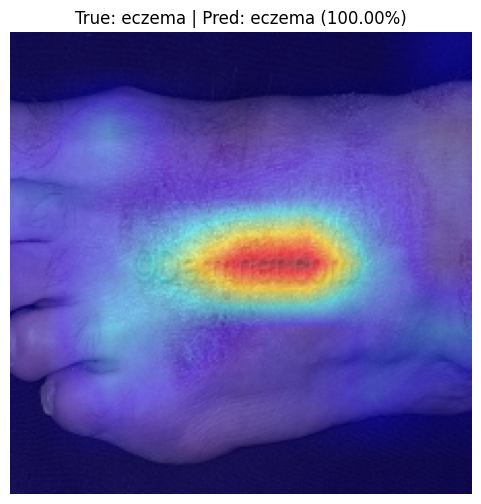

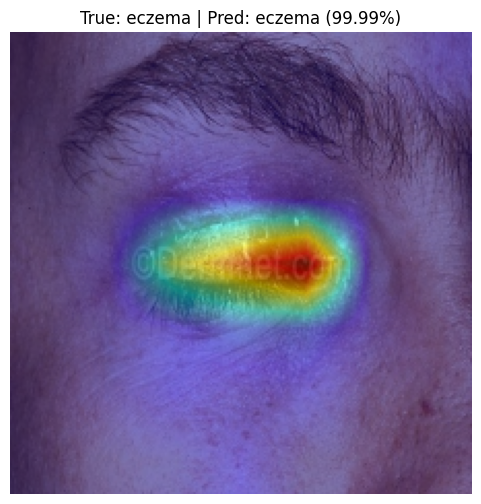

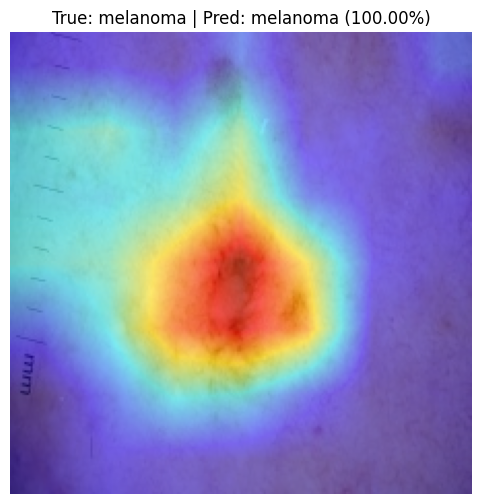

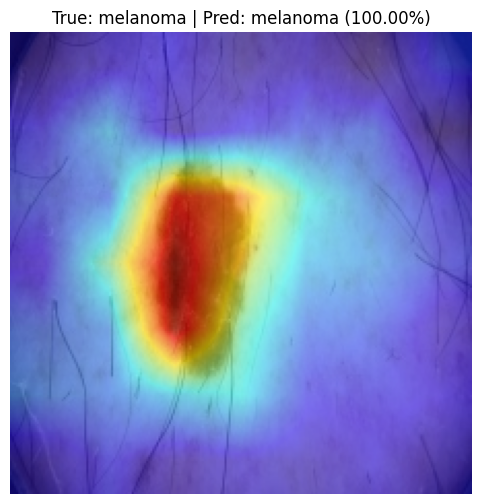

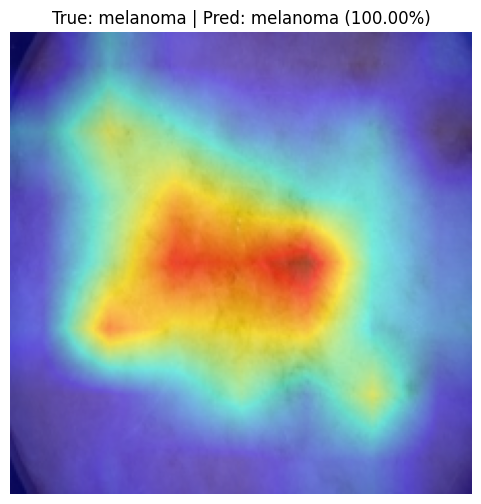

In [35]:
# Show Grad-CAM for a few test images
for idx in range(5):
    show_gradcam(efficientnet_model, cam, test_dataset, idx)